## Final Model Evaluation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
project_root = Path.resolve(Path.cwd() / '../..')
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))

In [3]:
import mlflow
mlflow.set_tracking_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
mlflow.set_registry_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
experiment_name = "Production Time Prediction"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///D:/DEV/AIML/ProjectRepos/AzureML/templates/azureml/mlflow/artifacts', creation_time=1779115459900, experiment_id='1', last_update_time=1779115459900, lifecycle_stage='active', name='Production Time Prediction', tags={}, workspace='default'>

In [4]:
import pandas as pd

X_train = pd.read_parquet('../../data/split/production_time_train.parquet')
X_test = pd.read_parquet('../../data/split/production_time_test.parquet')

y_train = pd.read_parquet('../../data/split/production_time_train_target.parquet')['process_time']
y_test = pd.read_parquet('../../data/split/production_time_test_target.parquet')['process_time']

#### Pipeline Imports
Pipelines are built from the following components:
- Preprocessor
- Feature Creation (Domain)
- GMM Clusterer and Feature Adder
- Polynomial Features Creation
- Correlation Pruning
- KBest Feature Selector

Unlike plain joblib loads, which needs every custom transformer class to be imported, MLflow's model loading can handle custom transformers without explicit imports. This is because MLflow serializes the entire pipeline, including custom transformers, and can deserialize it without needing the original class definitions in the current environment.

In [16]:
import mlflow.sklearn

# load pipelines from MLflow
elasticnet_c_p_cr_kb_pipeline = mlflow.sklearn.load_model("models:/elasticnet_c_p_cr_kb_pipeline/latest")
elasticnet_vp_c_p_cr_kb_pipeline = mlflow.sklearn.load_model("models:/elasticnet_vp_c_p_cr_kb_pipeline/latest")

final_pipelines = {
    'elasticnet_c_p_cr_kb_pipeline': elasticnet_c_p_cr_kb_pipeline,
    'elasticnet_vp_c_p_cr_kb_pipeline': elasticnet_vp_c_p_cr_kb_pipeline
}

for final_pipeline in final_pipelines.keys():
    final_pipelines[final_pipeline] = final_pipelines[final_pipeline].fit(X_train, y_train)

Legend for pipeline names:
- `_c`: GMM Clusterer and Feature Adder
- `_p`: Polynomial Features
- `_cr`: Correlation Pruning
- `_kb`: KBest Feature Selector
- `_vp`: Variance Penalty applied in Optuna hyperparameter tuning


---
#### Pipelines overview

In [17]:
from IPython.display import display, Markdown
for model_name, pipeline in final_pipelines.items():
    display(Markdown(f"### Final Pipeline for `{model_name.lower()}`"))
    display(pipeline)

### Final Pipeline for `elasticnet_c_p_cr_kb_pipeline`

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_creation', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,density_steel,7850
,mat_allowance,600
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

### Final Pipeline for `elasticnet_vp_c_p_cr_kb_pipeline`

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_creation', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,density_steel,7850
,mat_allowance,600
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa


---
#### Evaluation Metrics
The final pipelines are evaluated on the test set using the following metrics:
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R-squared (R2)

Loading the best baseline model for comparison:

In [18]:
import mlflow.sklearn

linear_baseline_model = mlflow.sklearn.load_model("models:/linear_baseline_model/latest")
tree_baseline_model = mlflow.sklearn.load_model("models:/baseline_model/latest")

pipelines = {
    'linear_baseline_model': linear_baseline_model,
    'tree_baseline_model': tree_baseline_model
}

Evaluating the final pipelines on the test set and comparing with the baseline model:

In [19]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

eval_ = []

for model_name, final_pipeline in {**pipelines, **final_pipelines}.items():
    final_pipeline.fit(X_train, y_train)
    y_test_predicted = final_pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_test_predicted)
    rmse = root_mean_squared_error(y_test, y_test_predicted)
    mae = mean_absolute_error(y_test, y_test_predicted)
    r2 = r2_score(y_test, y_test_predicted)

    eval_.append({
        'Model': model_name.lower(),
        'Test RMSE': rmse,
        'Test MAE': mae,
        'Test R2': r2
    })

df_eval_ = pd.DataFrame(eval_)
display(df_eval_.sort_values('Test RMSE').reset_index(drop=True))

,Model,Test RMSE,Test MAE,Test R2
0,tree_baseline_model,35.932415,17.683475,0.866851
1,elasticnet_c_p_cr_kb_pipeline,41.953277,20.659689,0.818492
2,elasticnet_vp_c_p_cr_kb_pipeline,42.697854,20.548836,0.811992
3,linear_baseline_model,66.531245,26.797507,0.543527


Test set evaluation showed that linear models with additionam feature engineering greatly improved performance over linear baseline achieving and RMSE of around 41.95 compared to 66.53 for the linear baseline. The tree-based model still outperformed the linear models with an RMSE of around 35.93 but the gap has narrowed significantly. Despite that metrics showed until now that engineered linear pipelines beat the tree-based model on cross-validation, the test set evaluation revealed that the tree-based model still has an edge in terms of generalization performance. This highlights the importance of evaluating models on a separate test set to get a more accurate picture of their real-world performance.

Since the linear pipelines with all feature engineering steps are still much lighter than the tree-based model, they can be a good choice for deployment in scenarios where inference speed and resource constraints are a concern, while still providing a decent quality of predictions. Therefore, the final choice of model for deployment in AzureML is the linear pipeline with all feature engineering steps, as it offers a good balance between performance and efficiency for my use case.

#### Visual vs. Quantitative Performance Analysis

### Parity Residuals Plot for `linear_baseline_model`

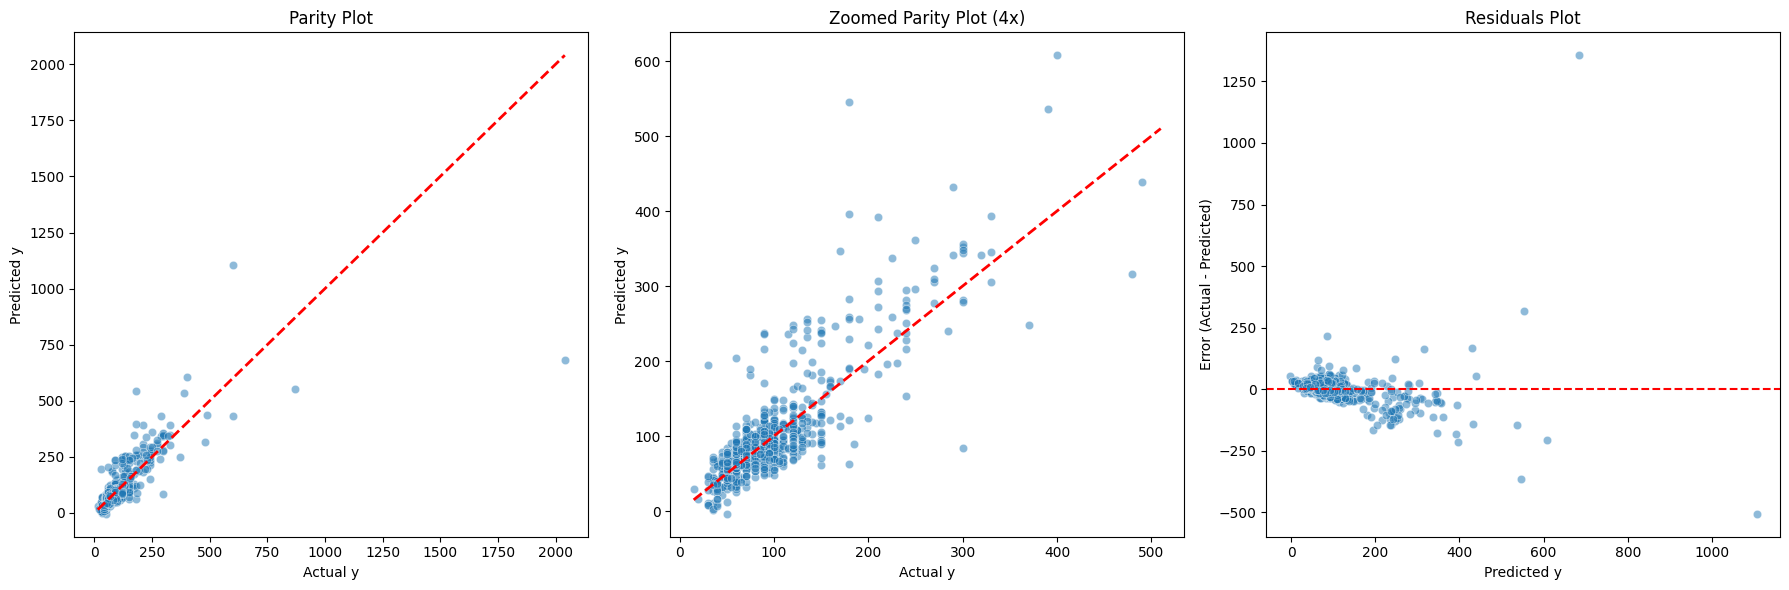

### Parity Residuals Plot for `tree_baseline_model`

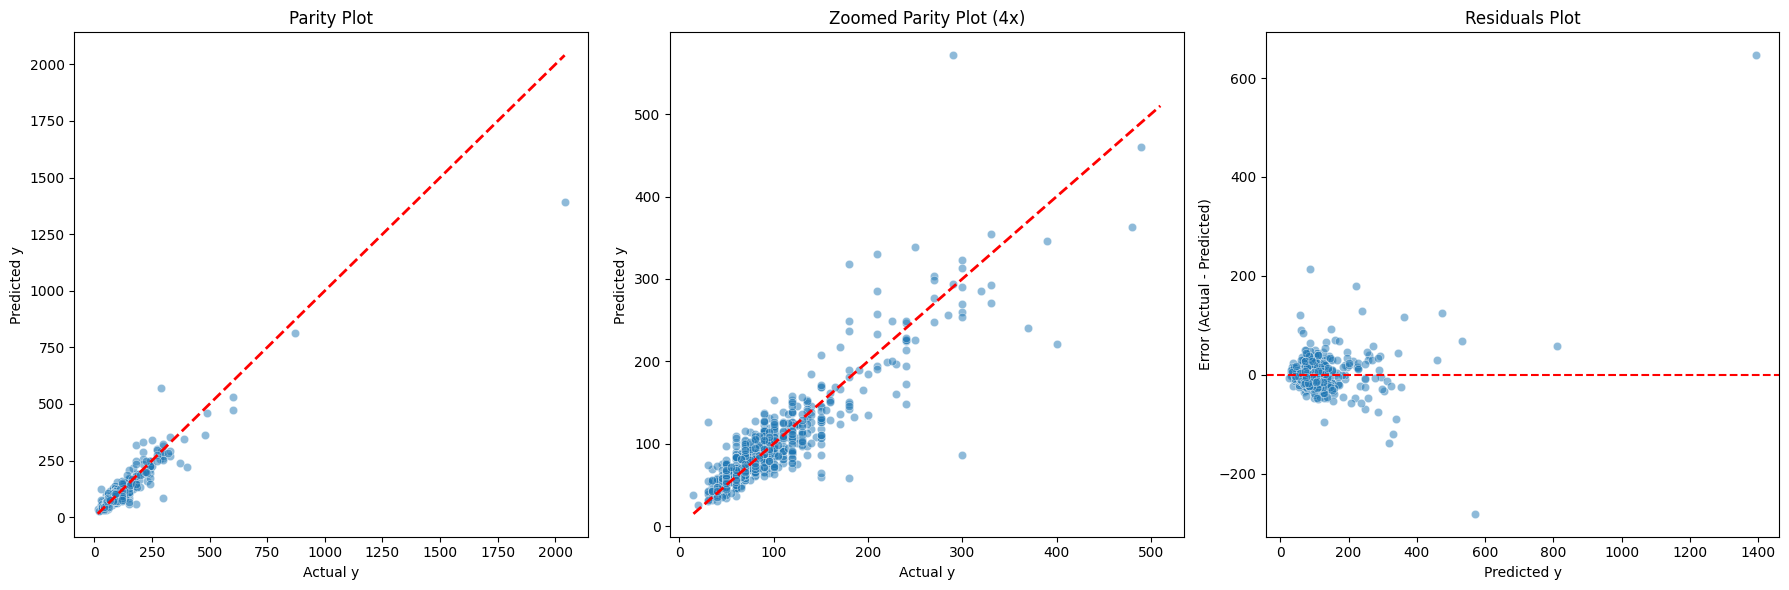

### Parity Residuals Plot for `elasticnet_c_p_cr_kb_pipeline`

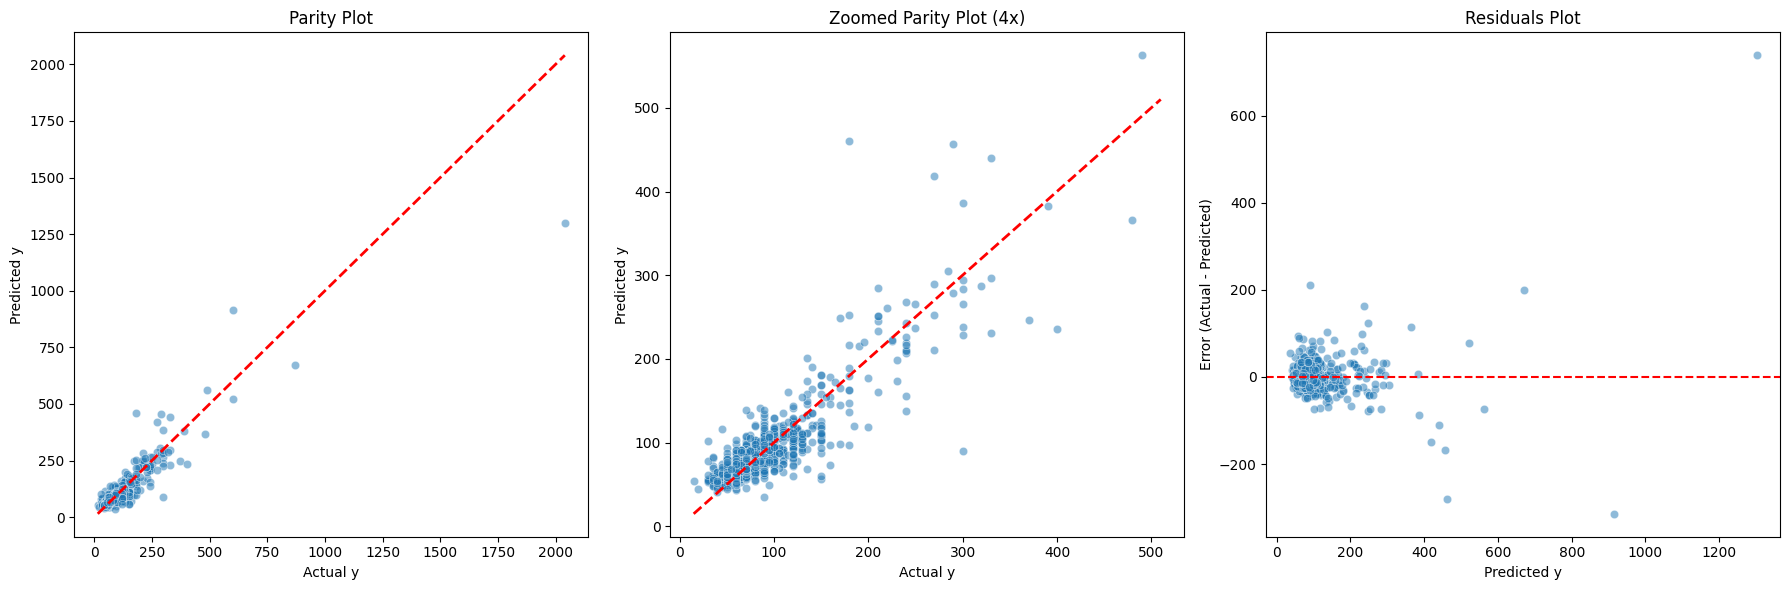

### Parity Residuals Plot for `elasticnet_vp_c_p_cr_kb_pipeline`

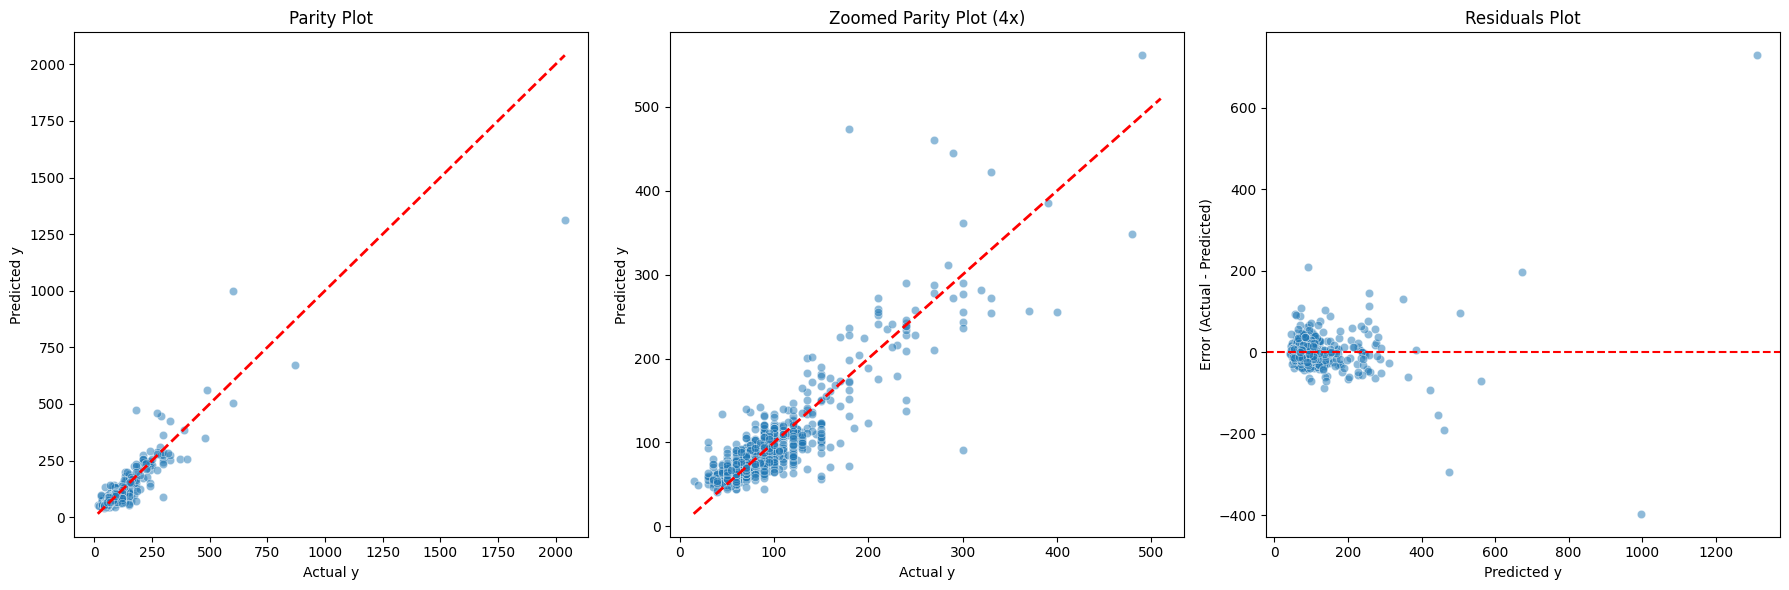

In [28]:
from notebooks.utils.model.model_diagnostics import ModelDiagnostics
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import mlflow.sklearn

base_pipeline = Pipeline(steps=[
    ('preprocessor', mlflow.sklearn.load_model("models:/preprocess_pipeline/latest")),
    ('model', LinearRegression())
])
base_pipeline.fit(X_train, y_train)
y_test_predicted = base_pipeline.predict(X_test)


for model_name, final_pipeline in {'linear_baseline_model': base_pipeline, **pipelines, **final_pipelines}.items():
    display(Markdown(f"### Parity Residuals Plot for `{model_name.lower()}`"))
    ModelDiagnostics.plot_parity_residuals(
        model=final_pipeline,
        X_test=X_test,
        y_test=y_test,
        scale=0.25
    )

An analysis of the residual and "Target vs. Predicted" plots reveals that the visual geometric distribution of errors remains highly similar across all evaluated architectures, including both the baseline models and the highly optimized tree and linear pipelines. 

While quantitative metrics indicate a profound improvement in model capacity, demonstrated by the 46% reduction in RMSE from the linear baseline (66.53) to the optimized tree model (35.93), this shift is not immediately apparent to the naked eye. This phenomenon can be mathematically attributed to two primary factors:

1. **Dominance of Extreme Outliers on Plot Scaling:** The visual boundaries and axes of the residual plots are heavily distorted by a small, identical subset of anomalous observations that all models struggle to predict accurately. These extreme residuals stretch the plot coordinates, masking the fact that for the vast majority of core data points, the optimized pipelines successfully pulled the predictions significantly closer to the zero-error line.

2. **Sensitivity of Quadratic Metrics:** The dramatic drop in RMSE indicates that the optimization frameworks (both Optuna hyperparameter tuning and feature selection via KBest) were exceptionally effective at mitigating large, squared errors. Reducing a few catastrophic mispredictions mathematically slashes the RMSE and R² metrics, while leaving the overall density and shape of the primary scatter plot cloud largely unaltered.

Consequently, this discrepancy proves that relying solely on visual inspection can be deceptive in regression analysis, and the true architectural significance of the optimized models is determined mainly by the cross-validated quantitative metrics.


---
---